# 4.0 LDAClassifier — 템플릿 공격 · Normal ∥ Masked

## 이 노트북이 답하는 질문

**타겟과 같은 장비를 미리 만질 수 있다면** 얼마나 강해지는가?

CPA(3.0)는 "해밍 가중치로 샐 것" 이라는 **가정**을 세우고 상관을 잰다. 가정이 틀리면 약해진다.
프로파일링 공격은 가정 대신 **측정**한다 — 키를 아는 장비에서 중간값별 누설 분포를 학습해
두고, 공격 대상 Trace(트레이스)가 어느 분포에서 나왔는지 따진다.

`scalib.modeling.LDAClassifier` 는 그 학습·판정을 맡는다.

| | |
|---|---|
| 학습 | 타겟별 `/profiling` (랜덤 키·랜덤 평문) |
| 공격 | 타겟별 `/attack` (고정 키) |
| 하드웨어 | 불필요. `1.0.SNR` 선행 필요 (POI 창) |

**핵심 질문:** 3.0 의 CPA 는 Masked 에서 완패했다. 가정을 버리고 **측정**하면 달라지는가?

## LDA 가 하는 일

Trace에서 POI를 골라도 차원이 수십이다. 클래스가 256개인데 차원이 높으면 학습이 불안정하다.

LDA(선형 판별 분석)는 **클래스가 가장 잘 갈리는 방향** $p$ 개를 찾아 그 축으로 투영한다.
클래스 간 분산 $S_b$ 는 키우고 클래스 내 분산 $S_w$ 는 줄이는 방향이다. 투영 뒤에는
클래스마다 가우시안 하나로 모델링하고, 새 Trace가 오면 각 클래스의 확률을 계산한다.

$$ \Pr[\ v = j \mid \mathbf{l}\ ] \ \propto\ \mathcal{N}\big(\mathbf{W}^\top \mathbf{l};\ \mu_j,\ \Sigma\big) $$

출력은 **확률**이다. CPA 의 상관계수와 달리 그대로 곱하고 합쳐 쓸 수 있어,
SASCA(5.0)나 키랭크(6.0)로 이어진다.

## 마스킹 앞에서 프로파일링이 무력한 이유

프로파일링은 강력하지만 **"무엇의" 분포를 배울지는 사람이 정한다.**
라벨을 $\mathrm{SBOX}[p \oplus k]$ 로 두면, 마스킹된 타겟에서는 같은 라벨의 트레이스들이
$m$ 값에 따라 사방으로 흩어진다. 클래스 내 분산 $S_w$ 가 커지고 클래스 간 분산 $S_b$ 는
0 으로 가므로, LDA 가 찾을 "잘 갈리는 방향" 자체가 존재하지 않는다.

즉 마스킹은 **모델을 틀리게 만드는 것이 아니라 배울 것이 없게 만든다.**

---
## 1. `LDAClassifier` API

| 단계 | 코드 |
|:----:|------|
| 생성 | `lda = LDAClassifier(nc=256, p=8)` |
| 누적 | `lda.fit_u(traces, x)` — 여러 번 나눠 부를 수 있다 |
| 완료 | `lda.solve()` — 투영 행렬과 분포를 실제로 계산한다 |
| 판정 | `lda.predict_proba(traces)` → `(n, nc)` |

`p` 는 투영 차원이다. 너무 작으면 정보를 버리고, 너무 크면 학습이 불안정해진다.

> **`solve()` 를 부르지 않으면 `predict_proba` 가 실패한다.** `fit_u` 는 통계만 누적하고,
> 실제 분해는 `solve()` 에서 일어난다.

> **`LDAClassifier` 의 라벨은 1차원이다.** `SNR`·`Cpa`·`MultiLDA` 는 2차원인데 여기만 다르다.
>
> | API | 라벨 shape | dtype |
> |-----|-----------|-------|
> | `Ttest` | `(n,)` | `uint16` |
> | `SNR`, `Cpa`, `MultiLDA` | `(n, nv)` | `uint16` |
> | `LDAClassifier` | `(n,)` | `uint16` |
> | `RLDAClassifier` | `(n, nv)` | `uint64` |
> | `RLDAInformationEstimator` | `(n,)` | `uint64` |
>
> Trace(`traces`)는 어디서나 `(n, ns)` `int16`이다.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from scalib_common import (
    TARGETS, TARGET_IDS, SBOX, HW, AES_BLOCK, sbox_out,
    load_group, load_poi, group_len, dataset_summary, require_target,
)

from scalib.modeling import LDAClassifier

BYTE = 0
N_ATK = 500
P_DIM = 3

# 비교는 양쪽 모두 **같은 예산**으로 한다. 트레이스 수가 다르면 "마스킹 때문에 어려운 것" 과
# "표본이 적어서 어려운 것" 이 섞여 해석이 불가능해진다.
AVAILABLE = {tid: group_len("profiling", tid) for tid in TARGET_IDS
             if require_target(tid)["dataset"].is_file()}
N_PROF = min(AVAILABLE.values())
print("프로파일링 보유 장수:", {TARGETS[t]["short"]: n for t, n in AVAILABLE.items()})
print("→ 공정 비교를 위해 양쪽 모두 %d 장만 쓴다." % N_PROF)

프로파일링 보유 장수: {'Normal': 100000, 'Masked': 100000}
→ 공정 비교를 위해 양쪽 모두 100000 장만 쓴다.


---
## 2. POI 창만 읽는다

Trace 전체를 메모리에 올릴 이유가 없다. `poi_windows`가 지정한 POI 근방 열만 골라 읽으면
10만 장이라도 수십 MB 다. `load_group(..., samples=cols)` 가 그 일을 한다.

읽은 뒤에는 원래 샘플 번호가 아니라 **압축된 배열 안에서의 위치**로 인덱싱해야 하므로
`np.searchsorted` 로 매핑한다. 이 변환을 빠뜨리면 엉뚱한 열을 학습하게 된다.

In [2]:
def load_windows(tid, n_prof, n_atk, key="poi_windows"):
    """POI 창에 해당하는 열만 읽어 (prof, atk, 바이트별 지역 인덱스) 를 돌려준다."""
    z = load_poi(tid)
    w = z[key].astype(int)                     # (16, 2*half+1) 원래 샘플 번호
    cols = np.unique(w.ravel())                # 실제로 읽을 열
    prof = load_group("profiling", target=tid, n=n_prof, samples=cols)
    atk = load_group("attack", target=tid, n=n_atk, samples=cols)
    loc = np.searchsorted(cols, w)             # 압축 배열 안에서의 위치
    return prof, atk, loc, cols


sets = {}
for tid in AVAILABLE:
    prof, atk, loc, cols = load_windows(tid, N_PROF, N_ATK)
    sets[tid] = (prof, atk, loc)
    print("[%s] prof%s  attack%s  읽은 열 %d개  바이트%d 창 %d샘플" % (
        TARGETS[tid]["short"], prof["t"].shape, atk["t"].shape,
        len(cols), BYTE, len(loc[BYTE])))

TRUE_KEY = np.array(sets[list(sets)[0]][1]["attrs"]["fixed_key"], dtype=np.uint8)
print()
print("정답 키 바이트%d = 0x%02x  (채점 전용)" % (BYTE, TRUE_KEY[BYTE]))

[Normal] prof(100000, 336)  attack(500, 336)  읽은 열 336개  바이트0 창 21샘플


[Masked] prof(100000, 336)  attack(500, 336)  읽은 열 336개  바이트0 창 21샘플

정답 키 바이트0 = 0x2f  (채점 전용)


---
## 3. 학습과 공격

공격 Trace의 평문은 알고 있다. 모델이 주는 것은 **SBox 출력 $v$의 확률**이므로,
키 후보 $g$ 의 확률로 옮기려면 $v = \mathrm{SBOX}[p \oplus g]$ 를 되짚으면 된다.

### 여러 장을 합치기

한 장으로는 부족해도 Trace가 여러 장이면 정보가 쌓인다. Trace는 서로 독립이므로
확률을 곱하면 되고, 수치 안정을 위해 **로그를 더한다.**

$$ \log \Pr[k = g] \ =\ \sum_i \log \Pr[\ v = \mathrm{SBOX}[p_i \oplus g]\ \mid\ \mathbf{l}_i\ ] $$

In [3]:
GUESS = np.arange(256, dtype=np.uint8)


def key_logprob(proba, plaintext_byte, mask=None):
    """중간값 확률을 256개 키 후보의 누적 로그확률로 변환한다.

    ``proba``는 ``(n, 256)``, ``plaintext_byte``는 길이 ``n``이어야 한다.
    ``mask``가 있으면 연구자 관점 라벨 ``SBOX[p^g] ^ m``을 사용한다. 0 확률은
    로그 발산을 막기 위해 ``1e-300``으로 제한한다. 형상이 맞지 않으면 NumPy
    예외가 발생하며 입력은 변경하지 않는다. 반환 형상은 ``(256,)``이다.
    """
    lp = np.log(np.maximum(proba, 1e-300))
    v = SBOX[np.bitwise_xor(plaintext_byte[:, None], GUESS[None, :])]   # (n, 256)
    if mask is not None:
        v = np.bitwise_xor(v, mask[:, None].astype(np.uint8))
    return np.take_along_axis(lp, v, axis=1).sum(axis=0)


def rank_of(scores, true_val):
    """내림차순 ``scores``에서 ``true_val`` 인덱스의 0-based 순위를 반환한다.

    동점은 NumPy 정렬 순서에 따르며 ``true_val``이 유효 인덱스가 아니면 결과
    검색 과정에서 ``IndexError``가 발생한다. 입력은 변경하지 않는다.
    """
    return int(np.where(np.argsort(-scores) == true_val)[0][0])


def run_lda(tid, p_dim=P_DIM, n_prof=None, byte=BYTE):
    """한 타겟·바이트의 LDA를 학습해 공격 Trace 확률과 공격 split을 반환한다.

    전역 ``sets[tid]``의 profiling split과 POI 창을 사용한다. ``n_prof``가 없으면
    모든 profiling Record를 쓰고, 있으면 앞부분만 쓴다. LDA 학습·solve·추론에
    실패하면 SCALib 예외가 전달된다. 모델은 지역 변수지만 계산 자원을 사용하며
    Dataset이나 전역 매핑은 변경하지 않는다.
    """
    prof, atk, loc = sets[tid]
    n_prof = prof["t"].shape[0] if n_prof is None else n_prof
    w = loc[byte]
    y = sbox_out(prof["p"][:n_prof, byte], prof["k"][:n_prof, byte]).astype(np.uint16)

    lda = LDAClassifier(nc=256, p=p_dim)
    lda.fit_u(np.ascontiguousarray(prof["t"][:n_prof, w]), y)
    lda.solve()                       # ← 필수
    proba = lda.predict_proba(np.ascontiguousarray(atk["t"][:, w]))
    return proba, atk


results = {}
for tid in sets:
    proba, atk = run_lda(tid)
    lp = key_logprob(proba, atk["p"][:, BYTE])
    r = rank_of(lp, int(TRUE_KEY[BYTE]))
    # 파형 한 장만으로 정답 중간값이 1등인 비율
    y_true = sbox_out(atk["p"][:, BYTE], TRUE_KEY[BYTE])
    acc1 = float(np.mean(proba.argmax(axis=1) == y_true))
    results[tid] = (r, acc1, proba, atk)
    print("[%-8s] 학습 %d장, 공격 %d장 → 정답 키 순위 %3d   (한 장 적중률 %.3f, 무작위 %.4f)"
          % (TARGETS[tid]["short"], N_PROF, N_ATK, r, acc1, 1 / 256))

print()
if len(results) == 2:
    print("[비교] 같은 학습 예산·같은 공격 장수인데 결과가 갈린다.")
    for tid in results:
        print("  %-8s 키 순위 %3d" % (TARGETS[tid]["short"], results[tid][0]))
    r_m, acc_m = results["masked-aes-c"][0], results["masked-aes-c"][1]
    print()
    print("  무작위로 찍으면 순위 기댓값은 127.5, 한 장 적중률은 %.4f 다." % (1 / 256))
    if r_m > 64:
        print("  Masked 는 그 근처다 — 프로파일링으로도 얻은 것이 없다.")
    else:
        print("  Masked 는 무작위보다 낫다(순위 %d, 적중률 %.4f). 마스킹이 1차 누설을" % (r_m, acc_m))
        print("  **완전히** 없애지는 못했고, 학습 예산이 크면 그 잔여분이 드러난다는 뜻이다.")
        print("  다만 Normal 과는 격이 다르다 — 아래 4·5절에서 그 차이를 본다.")

[Normal  ] 학습 100000장, 공격 500장 → 정답 키 순위   0   (한 장 적중률 0.116, 무작위 0.0039)
[Masked  ] 학습 100000장, 공격 500장 → 정답 키 순위   7   (한 장 적중률 0.012, 무작위 0.0039)

[비교] 같은 학습 예산·같은 공격 장수인데 결과가 갈린다.
  Normal   키 순위   0
  Masked   키 순위   7

  무작위로 찍으면 순위 기댓값은 127.5, 한 장 적중률은 0.0039 다.
  Masked 는 무작위보다 낫다(순위 7, 적중률 0.0120). 마스킹이 1차 누설을
  **완전히** 없애지는 못했고, 학습 예산이 크면 그 잔여분이 드러난다는 뜻이다.
  다만 Normal 과는 격이 다르다 — 아래 4·5절에서 그 차이를 본다.


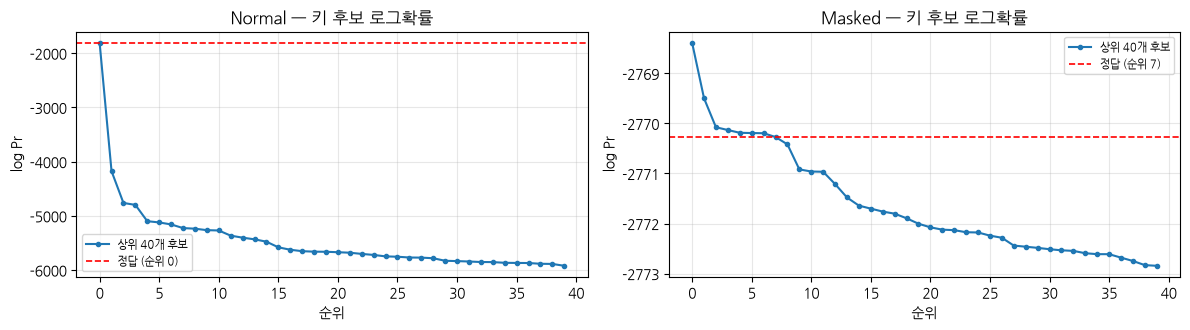

In [4]:
fig, axes = plt.subplots(1, len(results), figsize=(6.0 * len(results), 3.4))
if len(results) == 1:
    axes = [axes]
for ax, tid in zip(axes, results):
    r, acc1, proba, atk = results[tid]
    lp = key_logprob(proba, atk["p"][:, BYTE])
    order = np.argsort(-lp)
    ax.plot(lp[order][:40], "o-", ms=3, label="상위 40개 후보")
    ax.axhline(lp[TRUE_KEY[BYTE]], color="r", ls="--", lw=1.2,
               label="정답 (순위 %d)" % r)
    ax.set_title("%s — 키 후보 로그확률" % TARGETS[tid]["short"])
    ax.set_xlabel("순위"); ax.set_ylabel("log Pr")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

---
## 4. 공격 트레이스 수를 늘리면

Normal 은 몇 장 만에 정답이 1등으로 올라오는지, Masked 는 늘려도 올라오지 않는지 본다.

[Normal  ] 1장:8 2장:2 5장:0 10장:0 25장:0 50장:0 100장:0 250장:0 500장:0
[Masked  ] 1장:248 2장:250 5장:193 10장:229 25장:40 50장:47 100장:48 250장:7 500장:7


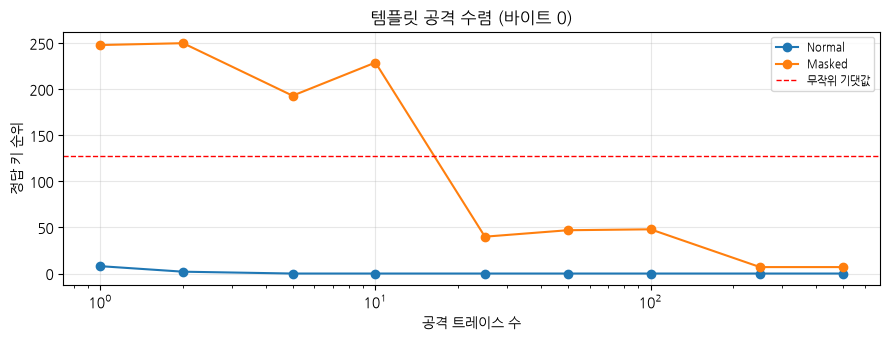

In [5]:
STEPS = [1, 2, 5, 10, 25, 50, 100, 250, 500]

curve = {}
for tid in results:
    _, _, proba, atk = results[tid]
    rr = []
    for m in STEPS:
        m = min(m, proba.shape[0])
        lp = key_logprob(proba[:m], atk["p"][:m, BYTE])
        rr.append(rank_of(lp, int(TRUE_KEY[BYTE])))
    curve[tid] = rr
    print("[%-8s] " % TARGETS[tid]["short"]
          + " ".join("%d장:%d" % (s, r) for s, r in zip(STEPS, rr)))

fig, ax = plt.subplots(figsize=(9, 3.5))
for tid in curve:
    ax.plot(STEPS, curve[tid], "o-", label=TARGETS[tid]["short"])
ax.axhline(127.5, color="r", ls="--", lw=1, label="무작위 기댓값")
ax.set_xscale("log"); ax.set_xlabel("공격 트레이스 수"); ax.set_ylabel("정답 키 순위")
ax.set_title("템플릿 공격 수렴 (바이트 %d)" % BYTE)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

---
## 5. 투영 차원 `p` 와 학습 트레이스 수의 영향

`p`를 바꿔 가며 "정답이 1등인 비율"(Trace 한 장 기준)과 키 순위를 본다.
클래스가 256개이므로 학습 트레이스 수가 적으면 클래스당 레코드가 부족해 모델이 흔들린다.

In [6]:
print("%-8s %4s %10s %14s %10s" % ("타겟", "p", "학습장수", "한 장 적중률", "키 순위"))
for tid in sets:
    prof, atk, loc = sets[tid]
    y_true = sbox_out(atk["p"][:, BYTE], TRUE_KEY[BYTE])
    for p_dim in (1, 3, 6):
        for n_p in (2000, N_PROF):
            try:
                proba, _ = run_lda(tid, p_dim=p_dim, n_prof=n_p)
            except Exception as e:
                print("%-8s %4d %10d   실패: %s" % (
                    TARGETS[tid]["short"], p_dim, n_p, type(e).__name__))
                continue
            acc1 = float(np.mean(proba.argmax(axis=1) == y_true))
            r = rank_of(key_logprob(proba, atk["p"][:, BYTE]), int(TRUE_KEY[BYTE]))
            print("%-8s %4d %10d %14.4f %10d" % (
                TARGETS[tid]["short"], p_dim, n_p, acc1, r))
    print()
print("무작위 적중률은 1/256 = %.4f 다. 그보다 유의하게 크지 않으면 배운 것이 없다." % (1 / 256))

타겟          p       학습장수        한 장 적중률       키 순위
Normal      1       2000         0.0300          0
Normal      1     100000         0.0340          0
Normal      3       2000         0.0900          0
Normal      3     100000         0.1160          0
Normal      6       2000         0.0920          0
Normal      6     100000         0.1300          0

Masked      1       2000         0.0020         61
Masked      1     100000         0.0020         39
Masked      3       2000         0.0020         96
Masked      3     100000         0.0120          7
Masked      6       2000         0.0020        108


Masked      6     100000         0.0080         10

무작위 적중률은 1/256 = 0.0039 다. 그보다 유의하게 크지 않으면 배운 것이 없다.


---
## 6. 연구자 관점 — 라벨을 바꾸면 프로파일링이 살아난다

3.0 §6 에서 `Cpa` 는 **트레이스마다 다른 마스크를 모델에 넣을 수 없어서** numpy 로
직접 계산해야 했다. LDA 는 다르다.

**LDA 의 라벨은 원래 트레이스마다 다른 값이다.** 그러니 라벨을
$\mathrm{SBOX}[p \oplus k] \oplus m_5$ 로 바꿔 넣기만 하면 된다. API 를 우회할 필요가 없다.

> **교훈 — API 선택 기준:** 모델이 트레이스에 무관하면 `Cpa` 가 빠르고 편하다.
> 모델이 트레이스마다 달라야 하면 라벨 기반인 `LDAClassifier` 계열을 쓴다.
> 이것이 두 API 의 실질적인 갈림길이다.

공격 단계에서도 마스크를 알아야 키 후보로 되짚을 수 있다
($v_g = \mathrm{SBOX}[p \oplus g] \oplus m_5$). `key_logprob(..., mask=...)` 가 그 부분이다.

창은 1.0 이 저장한 `poi_research_windows`(마스킹된 SBox 출력이 새는 지점)를 쓴다.

### 바이트 하나만 보면 안 된다

앞 절들은 설명을 위해 바이트 0 만 다뤘다. 그런데 1.0 §10 에서 본 것처럼 **연구자 라벨의
SNR 은 바이트마다 크게 다르다**(0.072 ~ 0.221). 바이트 0 은 그중 약한 축이다.
약한 바이트 하나를 골라 "안 된다" 고 하거나 강한 바이트 하나를 골라 "된다" 고 하는 것은
둘 다 체리피킹이다. 여기서는 **16바이트를 전부** 돌려 몇 개가 복구되는지 센다.

In [7]:
tid = "masked-aes-c"
if tid not in sets or sets[tid][0]["m"] is None:
    print("Masked HDF5 `mask` 배열 없음 — 연구자 절 건너뜀")
else:
    prof_a, atk_a, loc_a = sets[tid]                      # 공격자 창
    prof_r, atk_r, loc_r, _ = load_windows(tid, N_PROF, N_ATK,
                                           key="poi_research_windows")
    m_prof, m_atk = prof_r["m"][:, 5], atk_r["m"][:, 5]
    z = load_poi(tid)

    def lda_rank(prof, atk, w, y, byte, mask_atk=None):
        """지정 창과 라벨로 LDA를 학습해 정답 키 바이트의 순위를 반환한다.

        ``prof``와 ``atk``는 Trace·평문 배열을 가진 split 매핑이고 ``w``는 사용할
        Sample 인덱스다. ``y``는 profiling 라벨이며 ``mask_atk``가 있으면 연구자
        관점의 공격 라벨을 계산한다. 형상 또는 클래스 조건이 맞지 않으면 NumPy나
        SCALib 예외가 전달되며 입력 Dataset은 변경하지 않는다.
        """
        lda = LDAClassifier(nc=256, p=P_DIM)
        lda.fit_u(np.ascontiguousarray(prof["t"][:, w]), y.astype(np.uint16))
        lda.solve()
        proba = lda.predict_proba(np.ascontiguousarray(atk["t"][:, w]))
        lp = key_logprob(proba, atk["p"][:, byte], mask=mask_atk)
        return rank_of(lp, int(TRUE_KEY[byte]))

    r_att, r_res = [], []
    for b in range(AES_BLOCK):
        r_att.append(lda_rank(
            prof_a, atk_a, loc_a[b],
            sbox_out(prof_a["p"][:, b], prof_a["k"][:, b]), b))
        r_res.append(lda_rank(
            prof_r, atk_r, loc_r[b],
            np.bitwise_xor(sbox_out(prof_r["p"][:, b], prof_r["k"][:, b]), m_prof),
            b, mask_atk=m_atk))

    r_att, r_res = np.array(r_att), np.array(r_res)
    print("%-34s %8s %12s" % ("라벨 / 창", "rank0", "평균 순위"))
    print("%-34s %6d/16 %12.1f" % ("공격자  SBOX[p^k]",
                                   int((r_att == 0).sum()), r_att.mean()))
    print("%-34s %6d/16 %12.1f" % ("연구자  SBOX[p^k]^m5",
                                   int((r_res == 0).sum()), r_res.mean()))
    print()
    print("바이트별 순위 (공격자):", r_att.tolist())
    print("바이트별 순위 (연구자):", r_res.tolist())
    print()
    print("%-6s %12s %12s" % ("바이트", "연구자 SNR", "연구자 순위"))
    snr_r = z["snr_peak_research"]
    for b in np.argsort(-snr_r)[:6]:
        print("%-6d %12.4f %12d" % (b, snr_r[b], r_res[b]))
    print("...")
    for b in np.argsort(snr_r)[:3]:
        print("%-6d %12.4f %12d" % (b, snr_r[b], r_res[b]))
    print()
    print("연구자 라벨의 SNR 과 순위를 나란히 보면 같은 대상을 보고 있음이 드러난다.")
    if (r_res == 0).all():
        print("이 데이터셋에서는 16바이트가 전부 1등이다 — 마스크를 아는 순간")
        print("마스킹은 방어로서 아무 역할도 하지 못한다.")
    else:
        bad = [int(b) for b in np.flatnonzero(r_res != 0)]
        print("복구되지 않은 바이트 %s 는 연구자 라벨 SNR 자체가 낮다." % bad)
        print("즉 '마스크를 알면 무조건 뚫린다' 가 아니라 **그 바이트가 실제로 새는 만큼** 뚫린다.")

라벨 / 창                                rank0        평균 순위
공격자  SBOX[p^k]                          1/16        130.6
연구자  SBOX[p^k]^m5                      16/16          0.0

바이트별 순위 (공격자): [7, 220, 229, 255, 82, 108, 110, 145, 203, 11, 72, 109, 185, 138, 0, 215]
바이트별 순위 (연구자): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

바이트         연구자 SNR       연구자 순위
0            0.9255            0
1            0.9098            0
14           0.9094            0
8            0.9007            0
4            0.8762            0
2            0.8449            0
...
10           0.7731            0
3            0.7807            0
7            0.7900            0

연구자 라벨의 SNR 과 순위를 나란히 보면 같은 대상을 보고 있음이 드러난다.
이 데이터셋에서는 16바이트가 전부 1등이다 — 마스크를 아는 순간
마스킹은 방어로서 아무 역할도 하지 못한다.


---
## 7. 요약

| 항목 | 내용 |
|------|------|
| 목적 | 프로파일링으로 중간값의 **확률**을 얻고, 그것으로 키를 복구한다 |
| API | `LDAClassifier(nc, p)` → `fit_u(traces, x)` → `solve()` → `predict_proba(traces)` |
| `x` | `(n,)` `uint16` — **1차원**. `SNR`·`Cpa`·`MultiLDA` 와 다르다 |
| 출력 | `(n, nc)` 확률. 로그를 더해 여러 장을 합칠 수 있다 |
| CPA 와 차이 | 누설 모델을 **가정하지 않고 측정**한다. 대신 프로파일링 장비가 필요하다 |
| 공정 비교 | 두 타겟의 보유 트레이스 수가 다르므로 **같은 예산**으로 맞춰 비교한다 |

### 이 Dataset(데이터셋)에서 관측한 것

- Normal은 Trace 몇 개만으로 키 바이트가 1등으로 올라온다. CPA보다 훨씬 적은 트레이스 수다.
- Masked 는 3.0 의 CPA 로는 전혀 뚫리지 않았는데, 프로파일링에서는 **일부 바이트가**
  무작위보다 나은 순위를 받는다. 마스킹이 1차 누설을 완전히 지우지는 못했고,
  학습 예산이 커지면 그 잔여분이 통계적으로 드러나기 때문이다(§5의 학습 트레이스 수 표).
  그래도 16바이트를 다 세우지는 못하므로 **키 복구에는 이르지 못한다** — 그 규모를
  숫자로 보는 것이 6.0 이다.
- 라벨에 마스크를 넣으면 같은 Trace에서 순위가 살아난다 — 방어의 근거는 난수의 비밀성이다.

### 실패 시 점검

1. `solve()` 를 부르지 않으면 `predict_proba` 가 실패한다.
2. 정답 확률이 1/256 근처에 머문다 → POI가 틀렸거나 학습 트레이스 수가 부족하다.
   **대책이 걸려 있어서일 수도 있다** — 1.0 SNR 로 그 중간값이 애초에 새는지부터 본다.
3. `p` 가 클수록 항상 좋지는 않다. §5 표로 고른다.
4. `samples=` 로 압축해 읽었다면 POI 인덱스를 `searchsorted` 로 옮겼는지 확인한다.

다음: `4.1.MultiLDA.ipynb` — 16바이트를 한 번에.